In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 117.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
import transformers

print("Transformers version:", transformers.__version__)

Transformers version: 5.14.1


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-07-28 162431 fine tuning .png to Screenshot 2026-07-28 162431 fine tuning .png


In [ ]:
image_path = next(iter(uploaded.keys()))

print("Uploaded image:", image_path)

Uploaded image: Screenshot 2026-07-28 162431 fine tuning .png


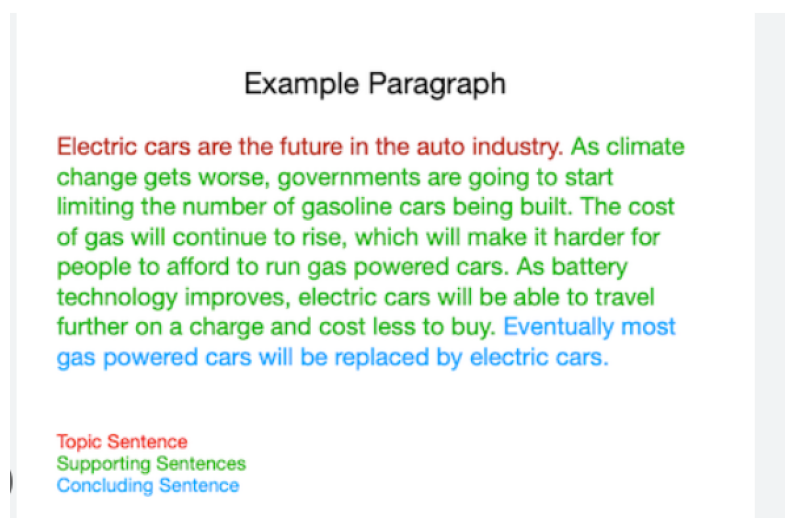

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForMultimodalLM

MODEL_NAME = "numind/NuExtract3"

processor = AutoProcessor.from_pretrained(MODEL_NAME)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    dtype=torch.float16
)

model.eval()

print("Model loaded successfully")

processor_config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/6.75k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.90k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 20.0MB            

...

model.safetensors: downloading bytes:           |  0.00B            

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

Model loaded successfully


In [ ]:
print("Model device:", model.device)
print("Model type:", type(model).__name__)

Model device: cuda:0
Model type: Qwen3_5ForConditionalGeneration


In [ ]:
instruction = """
Convert this document image into clean Markdown.

Rules:
- Extract all visible text accurately.
- Preserve the original reading order.
- Use # for the main title.
- Preserve the paragraph as one paragraph.
- Represent the color legend as a Markdown bullet list.
- Do not summarize.
- Do not explain the content.
- Do not add information.
- Return only Markdown.
"""

print(instruction)


Convert this document image into clean Markdown.

Rules:
- Extract all visible text accurately.
- Preserve the original reading order.
- Use # for the main title.
- Preserve the paragraph as one paragraph.
- Represent the color legend as a Markdown bullet list.
- Do not summarize.
- Do not explain the content.
- Do not add information.
- Return only Markdown.



In [ ]:
!pip install -q -U transformers accelerate datasets pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.8 MB/s eta 0:00:00


In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": instruction
            }
        ]
    }
]

print("Message created successfully")

Message created successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-07-28 162431 fine tuning .png to Screenshot 2026-07-28 162431 fine tuning  (1).png


In [ ]:
from PIL import Image

image_path = next(iter(uploaded.keys()))
image = Image.open(image_path).convert("RGB")

print("Image loaded:", image_path)

Image loaded: Screenshot 2026-07-28 162431 fine tuning  (1).png


In [ ]:
print(type(image))

<class 'PIL.Image.Image'>


In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": instruction
            }
        ]
    }
]

print("Message created successfully")

Message created successfully


In [ ]:
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
)

inputs = {
    key: value.to(model.device) if hasattr(value, "to") else value
    for key, value in inputs.items()
}

print("Input keys:", inputs.keys())

Input keys: dict_keys(['input_ids', 'attention_mask', 'mm_token_type_ids', 'pixel_values', 'image_grid_thw'])


In [ ]:
with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=500,
        do_sample=False
    )

print("Generation completed")

Generation completed


In [ ]:
prompt_length = inputs["input_ids"].shape[-1]

generated_ids = output_ids[0][prompt_length:]

markdown_output = processor.decode(
    generated_ids,
    skip_special_tokens=True
).strip()

print(markdown_output)

# Example Paragraph

Electric cars are the future in the auto industry. As climate change gets worse, governments are going to start limiting the number of gasoline cars being built. The cost of gas will continue to rise, which will make it harder for people to afford to run gas powered cars. As battery technology improves, electric cars will be able to travel further on a charge and cost less to buy. Eventually most gas powered cars will be replaced by electric cars.

* Topic Sentence
* Supporting Sentences
* Concluding Sentence


## Local Inference on GPU
Model page: https://huggingface.co/numind/NuExtract3

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/numind/NuExtract3)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
!nvidia-smi

In [ ]:
# Use a pipeline as a high-level helper
# Warning: Pipeline type "image-to-text" is no longer supported in transformers v5.
# You must load the model directly (see below) or downgrade to v4.x with:
# 'pip install "transformers<5.0.0'
from transformers import pipeline

pipe = pipeline("image-to-text", model="numind/NuExtract3")
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG"},
            {"type": "text", "text": "What animal is on the candy?"}
        ]
    },
]
pipe(text=messages)

In [ ]:
# Load model directly
from transformers import AutoProcessor, AutoModelForMultimodalLM

processor = AutoProcessor.from_pretrained("numind/NuExtract3")
model = AutoModelForMultimodalLM.from_pretrained("numind/NuExtract3", device_map="auto")
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG"},
            {"type": "text", "text": "What animal is on the candy?"}
        ]
    },
]
inputs = processor.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=40)
print(processor.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

In [ ]:
# NuExtract3 Fine-Tuning with QLoRA

In [ ]:
!pip install -q -U \
    transformers \
    accelerate \
    datasets \
    pillow \
    peft \
    trl \
    bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.2 MB/s eta 0:00:00


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
zip_path = next(iter(uploaded.keys()))

print("Uploaded file:", zip_path)

Uploaded file: archive (1).zip


In [ ]:
import os
import zipfile

DATASET_DIR = "/content/fine_tuning_dataset"

os.makedirs(DATASET_DIR, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as archive:
    archive.extractall(DATASET_DIR)

print("Dataset extracted to:", DATASET_DIR)

Dataset extracted to: /content/fine_tuning_dataset


In [ ]:
for current_root, folders, files_in_folder in os.walk(DATASET_DIR):
    level = current_root.replace(DATASET_DIR, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(current_root)}/")

    for filename in files_in_folder[:20]:
        print(f"{indent}    {filename}")

fine_tuning_dataset/
    annotations.xml
    receipts.csv
    images/
        2.jpg
        11.jpg
        14.jpg
        17.jpg
        0.jpg
        12.jpg
        15.jpg
        3.jpg
        7.jpg
        9.jpg
        10.jpg
        13.jpg
        16.jpg
        19.jpg
        1.jpg
        18.jpg
        5.jpg
        6.JPG
        4.jpg
        8.jpg
    boxes/
        13.png
        14.png
        2.png
        10.png
        18.png
        6.png
        15.png
        7.png
        16.png
        0.png
        9.png
        8.png
        3.png
        19.png
        4.png
        1.png
        12.png
        17.png
        5.png
        11.png


In [ ]:
import pandas as pd
import os

csv_path = os.path.join(DATASET_DIR, "receipts.csv")

df = pd.read_csv(csv_path)

print("Number of rows:", len(df))
print("Column names:", df.columns.tolist())

display(df.head())

Number of rows: 20
Column names: ['image_id', 'image_name']


,image_id,image_name
0,0,images/0.jpg
1,1,images/1.jpg
2,2,images/2.jpg
3,3,images/3.jpg
4,4,images/4.jpg


In [ ]:
import xml.etree.ElementTree as ET

xml_path = os.path.join(DATASET_DIR, "annotations.xml")

tree = ET.parse(xml_path)
root = tree.getroot()

print("Root tag:", root.tag)
print("Number of image entries:", len(root.findall("image")))

Root tag: annotations
Number of image entries: 20


In [ ]:
first_image = root.find("image")

print("Image information:")
print(first_image.attrib)

print("\nAnnotations:\n")

for child in first_image:
    print("Tag:", child.tag)
    print("Information:", child.attrib)

    for attribute in child.findall("attribute"):
        print(
            "Attribute:",
            attribute.attrib.get("name"),
            "=",
            attribute.text
        )

    print("-" * 60)

Image information:
{'id': '0', 'name': 'images/0.jpg', 'width': '612', 'height': '1023'}

Annotations:

Tag: polygon
Information: {'label': 'receipt', 'source': 'manual', 'occluded': '0', 'points': '39.15,93.53;186.88,67.24;270.27,54.55;332.35,48.66;447.00,54.10;537.19,63.62;593.83,73.13;609.24,67.24;612.00,71.84;612.00,784.65;605.62,862.11;596.10,926.01;589.75,936.89;514.98,931.90;388.54,926.01;196.85,918.31;91.72,913.32;83.56,895.65;72.68,852.60;67.24,800.48;87.64,776.01;118.45,725.71;148.82,680.39;155.61,643.23;153.35,605.16;144.28,587.49;133.41,571.63;108.94,562.56;91.72,561.66;71.78,582.96;50.93,593.38;44.13,521.33;34.16,431.14;25.10,325.10;21.93,270.72;21.93,220.87;25.10,157.43;31.90,110.30', 'z_order': '0'}
------------------------------------------------------------
Tag: box
Information: {'label': 'shop', 'source': 'manual', 'occluded': '0', 'xtl': '153.76', 'ytl': '194.59', 'xbr': '481.86', 'ybr': '245.40', 'rotation': '358.70', 'z_order': '0'}
Attribute: text = WALMART
------

In [ ]:
def annotation_to_markdown(image_element):
    shop_values = []
    item_values = []
    date_values = []
    total_values = []

    for annotation in image_element:
        # We only need text boxes.
        if annotation.tag != "box":
            continue

        label = annotation.attrib.get("label")
        text_value = ""

        # Find the text stored inside the box.
        for attribute in annotation.findall("attribute"):
            if attribute.attrib.get("name") == "text":
                text_value = (attribute.text or "").strip()

        # Ignore empty annotations.
        if not text_value:
            continue

        if label == "shop":
            shop_values.append(text_value)

        elif label == "item":
            item_values.append(text_value)

        elif label == "date_time":
            date_values.append(text_value)

        elif label == "total":
            total_values.append(text_value)

    markdown_lines = ["# Receipt"]

    if shop_values:
        markdown_lines.extend([
            "",
            "## Shop",
            "",
            "\n".join(shop_values)
        ])

    if item_values:
        markdown_lines.extend([
            "",
            "## Items",
            ""
        ])

        for item in item_values:
            markdown_lines.append(f"- {item}")

    if date_values:
        markdown_lines.extend([
            "",
            "## Date and Time",
            "",
            "\n".join(date_values)
        ])

    if total_values:
        markdown_lines.extend([
            "",
            "## Total",
            "",
            "\n".join(total_values)
        ])

    return "\n".join(markdown_lines).strip()

In [ ]:
first_markdown = annotation_to_markdown(first_image)

print(first_markdown)

# Receipt

## Shop

WALMART

## Items

- FRAP 001200010451 F 5.48 N
- BANANAS 000000004011KF 0.41 lb @ 1 lb /0.49 0.20 N

## Date and Time

08/20/10 13:12:01

## Total

TOTAL 5.11


In [ ]:
training_records = []

for image_element in root.findall("image"):
    # Example: images/0.jpg
    relative_image_path = image_element.attrib["name"]

    # Complete path:
    # /content/fine_tuning_dataset/images/0.jpg
    full_image_path = os.path.join(
        DATASET_DIR,
        relative_image_path
    )

    # Convert this image's XML annotations into Markdown
    markdown_target = annotation_to_markdown(image_element)

    # Make sure the image exists
    if not os.path.exists(full_image_path):
        print("Missing image:", full_image_path)
        continue

    training_records.append({
        "image_path": full_image_path,
        "markdown": markdown_target
    })

print("Number of training records:", len(training_records))

Number of training records: 20


In [ ]:
record_number = 1

print("IMAGE PATH:")
print(training_records[record_number]["image_path"])

print("\nCORRECT MARKDOWN TARGET:\n")
print(training_records[record_number]["markdown"])

IMAGE PATH:
/content/fine_tuning_dataset/images/1.jpg

CORRECT MARKDOWN TARGET:

# Receipt

## Shop

TRADER JOE'S

## Items

- MINI-PEARL TOMATOES.. 2.49
- PKG SHREDDED MOZZARELLA LITE T 3.99
- EGGS 1 DOZ ORGANIC BROWN. 3.79
- BEANS GARBANZO 0.89
- GROCERY NON TAXABLE 0.98 2@ 0.49
- A-AVOCADOS HASS BAG 4CT 3.99
- SPROUTED CA STYLE 2.99
- BANANAS ORGANIC 0.87 3EA @ 0.29/EA
- CREAMY SALTED PEANUT BUTTER 2.49
- WHL WHT PITA BREAD 1.69
- GROCERY NON TAXABLE 1.38 2 2@ 0.69
- R-CARROTS SHREDDED 10 OZ 1.29
- A-APPLE BAG JAZZ 2 LB 2.99
- A-PEPPER BELL EACH XL RED 0.99
- R-CUCUMBERS PERSIAN 1 LB 1.99
- TOMATOES CRUSHED NO SALT 1.59
- TOMATOES WHOLE NO SALT W/BASIL 1.59
- ORGANIC OLD FASHIONED OATMEAL 2.69

## Date and Time

06-28-2014 12:34PM

## Total

TOTAL $38.68


In [ ]:
print("Total records:", len(training_records))

for index, record in enumerate(training_records):
    image_exists = os.path.exists(record["image_path"])
    markdown_text = record["markdown"].strip()

    if not image_exists:
        print(f"Missing image in record {index}: {record['image_path']}")

    if markdown_text == "# Receipt":
        print(f"No labelled text in record {index}")

print("Validation complete")

Total records: 20
Validation complete


In [ ]:
TRAINING_INSTRUCTION = """
Perform OCR on this receipt image and convert the extracted information into structured Markdown.

Rules:
- Use # Receipt as the main title.
- Use ## Shop for the shop name.
- Use ## Items for purchased items.
- Format each purchased item as a Markdown bullet point.
- Use ## Date and Time for the date and time.
- Use ## Total for the total.
- Copy the labelled text accurately.
- Do not summarize.
- Do not invent information.
- Return only Markdown.
""".strip()

print(TRAINING_INSTRUCTION)

Perform OCR on this receipt image and convert the extracted information into structured Markdown.

Rules:
- Use # Receipt as the main title.
- Use ## Shop for the shop name.
- Use ## Items for purchased items.
- Format each purchased item as a Markdown bullet point.
- Use ## Date and Time for the date and time.
- Use ## Total for the total.
- Copy the labelled text accurately.
- Do not summarize.
- Do not invent information.
- Return only Markdown.


In [ ]:
dataset_records = []

for record in training_records:
    dataset_records.append({
        "image": record["image_path"],
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image"
                    },
                    {
                        "type": "text",
                        "text": TRAINING_INSTRUCTION
                    }
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {
                        "type": "text",
                        "text": record["markdown"]
                    }
                ]
            }
        ]
    })

print("Dataset records:", len(dataset_records))

Dataset records: 20


In [ ]:
from datasets import Dataset, Image as DatasetImage

dataset = Dataset.from_list(dataset_records)

dataset = dataset.cast_column(
    "image",
    DatasetImage()
)

print(dataset)
print("\nDataset features:")
print(dataset.features)

Dataset({
    features: ['image', 'messages'],
    num_rows: 20
})

Dataset features:
{'image': Image(mode=None, decode=True), 'messages': List({'role': Value('string'), 'content': List({'type': Value('string'), 'text': Value('string')})})}


Image type: <class 'PIL.WebPImagePlugin.WebPImageFile'>


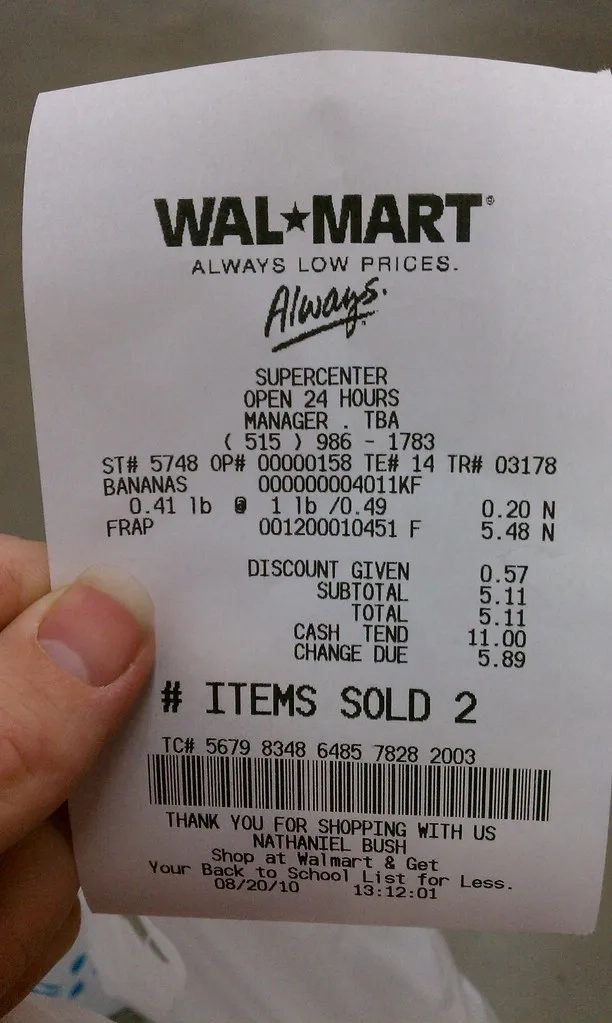


USER INSTRUCTION:

Perform OCR on this receipt image and convert the extracted information into structured Markdown.

Rules:
- Use # Receipt as the main title.
- Use ## Shop for the shop name.
- Use ## Items for purchased items.
- Format each purchased item as a Markdown bullet point.
- Use ## Date and Time for the date and time.
- Use ## Total for the total.
- Copy the labelled text accurately.
- Do not summarize.
- Do not invent information.
- Return only Markdown.

CORRECT MARKDOWN TARGET:

# Receipt

## Shop

WALMART

## Items

- FRAP 001200010451 F 5.48 N
- BANANAS 000000004011KF 0.41 lb @ 1 lb /0.49 0.20 N

## Date and Time

08/20/10 13:12:01

## Total

TOTAL 5.11


In [ ]:
sample = dataset[0]

print("Image type:", type(sample["image"]))

display(sample["image"])

print("\nUSER INSTRUCTION:\n")
print(
    sample["messages"][0]["content"][1]["text"]
)

print("\nCORRECT MARKDOWN TARGET:\n")
print(
    sample["messages"][1]["content"][0]["text"]
)